In [7]:
import os
import numpy as np
from PIL import Image

In [ ]:
def find_fg_indices(mask, axis):
	is_fg = mask.any(axis=axis)
	fg_indices = np.flatnonzero(is_fg)
	if fg_indices.size == 0:
		return None
	return fg_indices[0], fg_indices[-1]

class CropBackground:
	def __init__(self, threshold=5, scan_size=256):
		self.threshold = threshold
		self.scan_size = scan_size
		
	def __call__(self, img):
		
		arr = np.array(img)
		r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
		mask = (r > self.threshold) | (g > self.threshold) | (b > self.threshold)
		h, w = mask.shape
		row_bounds = find_fg_indices(mask, axis=1)
		col_bounds = find_fg_indices(mask, axis=0)
		rmin, rmax = row_bounds if row_bounds is not None else (0, h - 1)
		cmin, cmax = col_bounds if col_bounds is not None else (0, w - 1)
		return img.crop((cmin, rmin, cmax + 1, rmax + 1))


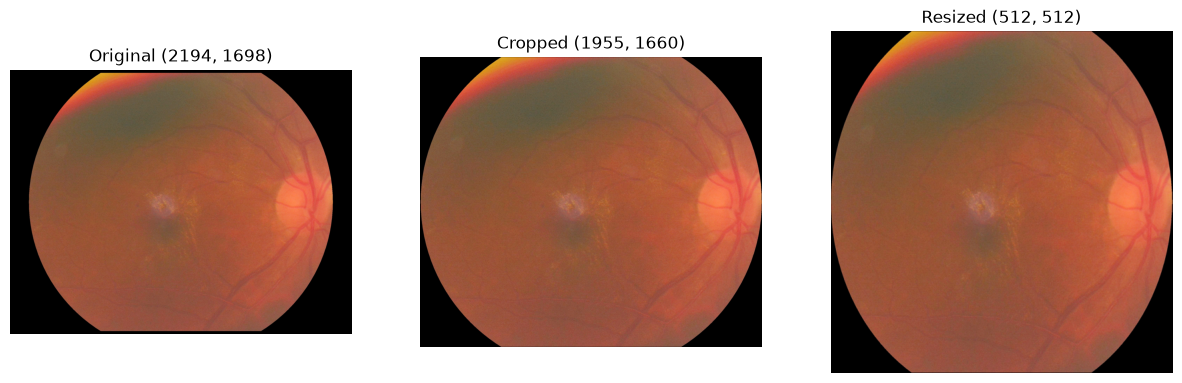

In [ ]:
import matplotlib.pyplot as plt
root = "./ddr/DDR-dataset/DR_grading"
img_name = "007-2945-100.jpg"
img_path = os.path.join(root, "test", img_name)

img = Image.open(img_path).convert("RGB")

crop = CropBackground(threshold=5)
cropped = crop(img)

resized = cropped.resize((512, 512))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original {img.size}")
axes[1].imshow(cropped)
axes[1].set_title(f"Cropped {cropped.size}")
axes[2].imshow(resized)
axes[2].set_title(f"Resized {resized.size}")
for ax in axes:
	ax.axis("off")
plt.show()

['007-0335-000.jpg', '007-1424-000.jpg', '007-3540-200.jpg', '007-0462-000.jpg', '007-3111-100.jpg', '20170226093451361.jpg']


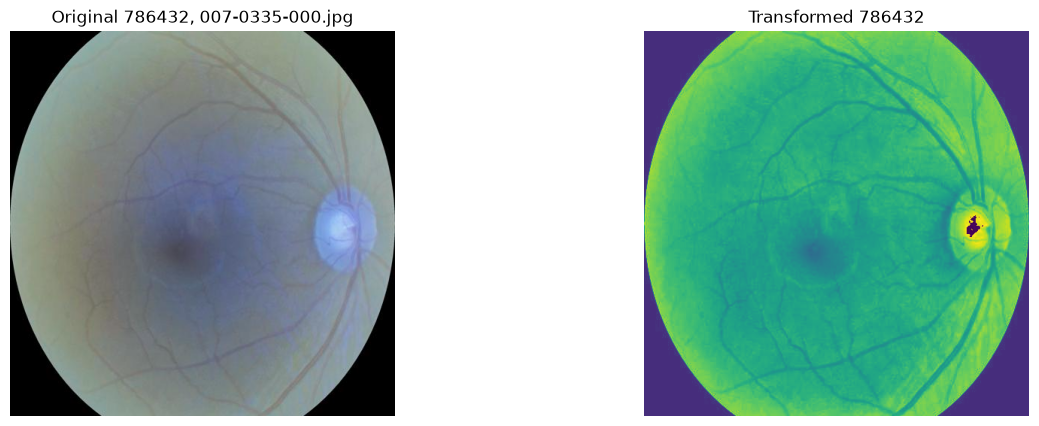

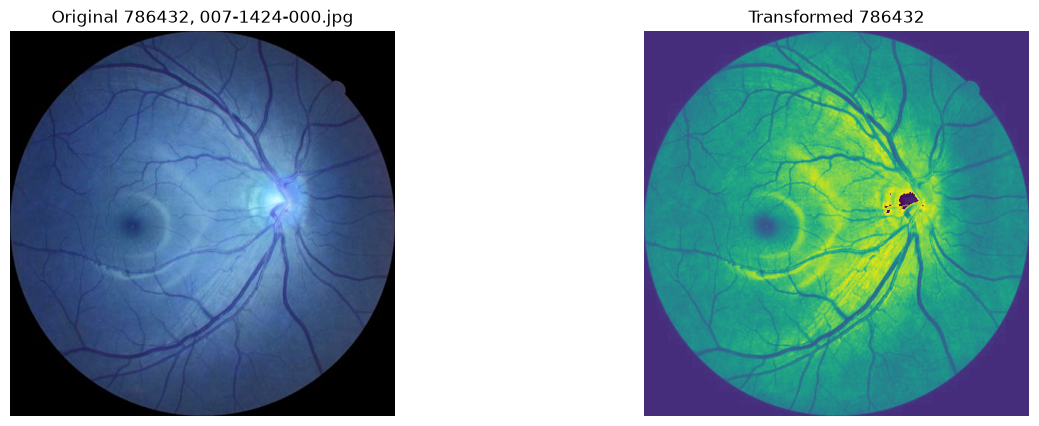

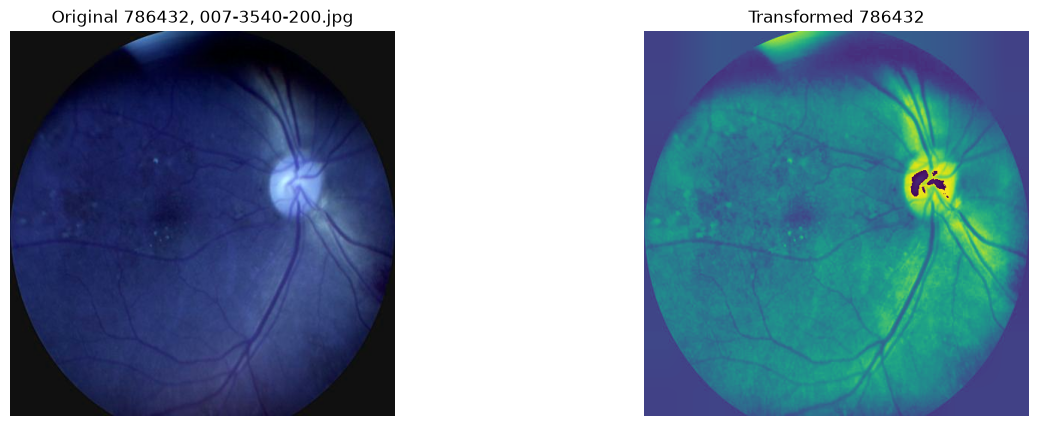

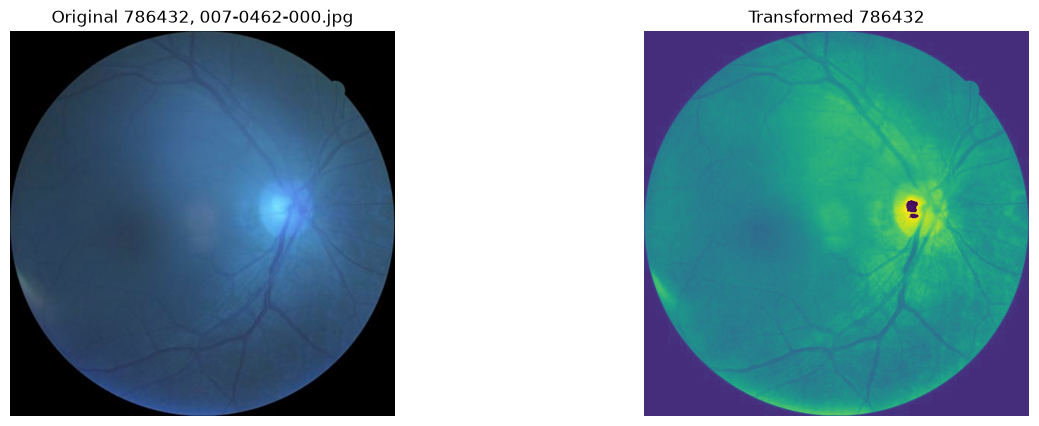

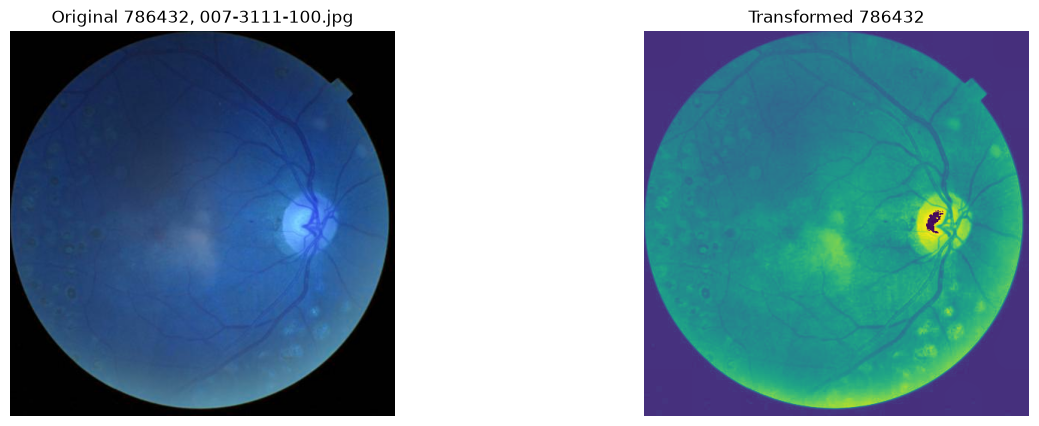

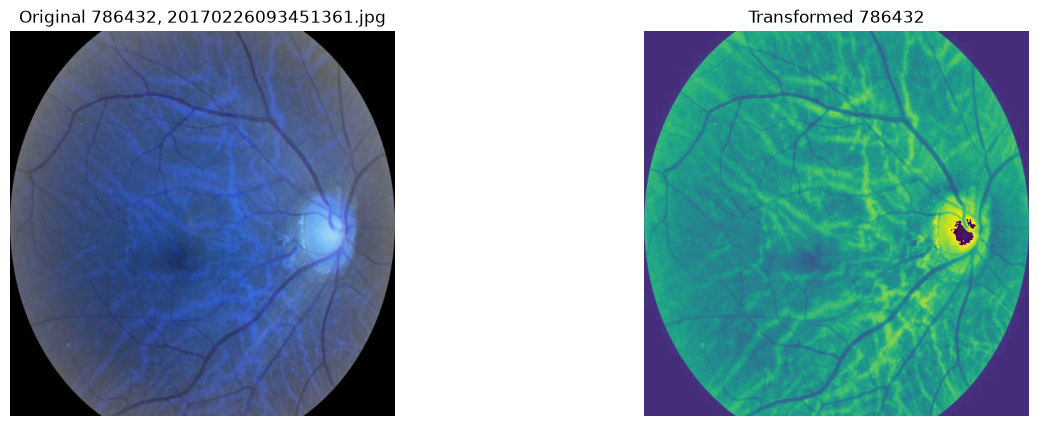

In [5]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

root = "./ddr/DDR-dataset/DR_grading"
name_list = os.path.join(root, "train512")
img_list = os.listdir(name_list)[:6]

print(img_list)

for img_name in img_list:
	img_path = os.path.join(root, "train512", img_name)
	img =  cv2.imread(img_path)
	
	fig, axes = plt.subplots(1, 2, figsize=(15, 5))
	axes[0].imshow(img)
	axes[0].set_title(f"Original {img.size}, {img_name}")
	image_bw = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
	clahe = cv2.createCLAHE(clipLimit=2)
	clahe_img = np.clip(clahe.apply(image_bw) + 30, 0, 255).astype(np.uint8)
	_, threshold_img = cv2.threshold(image_bw, 155, 255, cv2.THRESH_BINARY)
	axes[1].imshow(clahe_img)
	axes[1].set_title(f"Transformed {img.size}")
	for ax in axes:
		ax.axis("off")
plt.show()
